# Hospital Readmission Prediction


## Uploading Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

file_path = "/content/drive/MyDrive/BI_Projects/hospital_readmission_prediction/diabetic_data.csv"
df = pd.read_csv(file_path)

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## EDA

In [3]:
df.shape

(101766, 50)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
df["readmitted"].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [6]:
df["readmitted_30_days"] = (df["readmitted"] == "<30").astype(int)

In [7]:
df.isna().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [8]:
missing_question = (df == "?").sum().sort_values(ascending=False)
missing_question[missing_question > 0]

,0
weight,98569
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21


In [9]:
df["readmitted_30_days"].value_counts(normalize=True)

,proportion
readmitted_30_days,
0,0.888401
1,0.111599


In [10]:
import numpy as np

df_model = df.copy()

# Create clean target column
df_model["readmitted_30_days"] = (df_model["readmitted"] == "<30").astype(int)

# Drop columns that should not be used as model features
drop_cols = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "weight",
    "payer_code",
    "medical_specialty"
]

df_model = df_model.drop(columns=drop_cols)

# Replace "?" markers with "Unkown" in remaining categorical columns
df_model = df_model.replace("?", "Unknown")

# Treat missing lab result categorries as "Missing"
df_model["max_glu_serum"] = df_model["max_glu_serum"].fillna("Missing")
df_model["A1Cresult"] = df_model["A1Cresult"].fillna("Missing")

In [11]:
# Quick check
df_model.shape, df_model["readmitted_30_days"].value_counts(normalize=True)

((101766, 45),
 readmitted_30_days
 0    0.888401
 1    0.111599
 Name: proportion, dtype: float64)

In [12]:
df_model.isna().sum().sort_values(ascending=False).head(10)

,0
race,0
gender,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0


## Train-Test Split

In [13]:
X = df_model.drop(columns=["readmitted_30_days"])
y = df_model["readmitted_30_days"]

X.shape, y.shape

((101766, 44), (101766,))

In [14]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features", len(numeric_features))
print("Categorical features", len(categorical_features))

Numeric features 11
Categorical features 33


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train shape \n:", X_train.shape, y_train.shape)
print("Test shape \n:", X_test.shape, y_test.shape)

print("\nTrain target ratio :")
print(y_test.value_counts(normalize=True))
print("\nTest target ratio :")
print(y_test.value_counts(normalize=True))

Train shape 
: (81412, 44) (81412,)
Test shape 
: (20354, 44) (20354,)

Train target ratio :
readmitted_30_days
0    0.888425
1    0.111575
Name: proportion, dtype: float64

Test target ratio :
readmitted_30_days
0    0.888425
1    0.111575
Name: proportion, dtype: float64


## Preprocessing + Logistic Regression baseline

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [17]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Baseline model
log_reg_model = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter = 1000,
            class_weight = "balanced",
            random_state = 42
        ))
    ]
)

In [18]:
# Train
log_reg_model.fit(X_train, y_train)

# Predict
y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate
print("Classification Report :")
print(classification_report(y_test, y_pred))

print("ROC-AUC :", roc_auc_score(y_test, y_pred))

print("Confusion Matrix :")
print(confusion_matrix(y_test, y_pred))

Classification Report :
              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18083
           1       0.17      0.55      0.26      2271

    accuracy                           0.64     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.64      0.71     20354

ROC-AUC : 0.602564954840434
Confusion Matrix :
[[11871  6212]
 [ 1025  1246]]


### Why Recall Matters  ⚓

In this project, the positive class is `readmitted_30_days = 1`, meaning the patient was readmitted within 30 days.

Since this class represents only about 11% of the dataset, accuracy alone can be misleading. Recall is important because it shows how many truly readmitted patients the model can correctly identify.

For the baseline Logistic Regression model, recall for class `1` is 0.55. This means the model catches about 55% of patients who were actually readmitted within 30 days, but still misses many high-risk cases.

Precision for class `1` is 0.17, meaning many predicted high-risk cases are false alarms. Therefore, future improvements should focus on balancing recall, precision, and F1-score rather than optimizing accuracy alone.

in Turkish we say:  

Class 1 recall = 0.55
Gerçekten 30 gün içinde hastaneye dönen hastaların %55’ini model yakalamış.  

Class 1 precision = 0.17
Modelin “30 gün içinde dönecek” dediği hastaların sadece %17’si gerçekten dönmüş.  

Class 0 precision = 0.92
Modelin “30 gün içinde dönmeyecek” dediği hastaların %92’si gerçekten dönmemiş.  

Class 0 recall = 0.66
Gerçekten 30 gün içinde dönmeyen hastaların %66’sını model doğru şekilde “dönmeyecek” diye sınıflandırmış.  

## Numeric Feature Distribution and Skewness Check

In [19]:
# Numeric feature skewness

skewness = X_train[numeric_features].skew().sort_values(ascending=False)
skewness

,0
number_emergency,24.319951
number_outpatient,8.664200
number_inpatient,3.609746
discharge_disposition_id,2.558927
admission_type_id,1.593940
num_medications,1.325054
num_procedures,1.316930
time_in_hospital,1.139914
admission_source_id,1.027683
num_lab_procedures,-0.237080


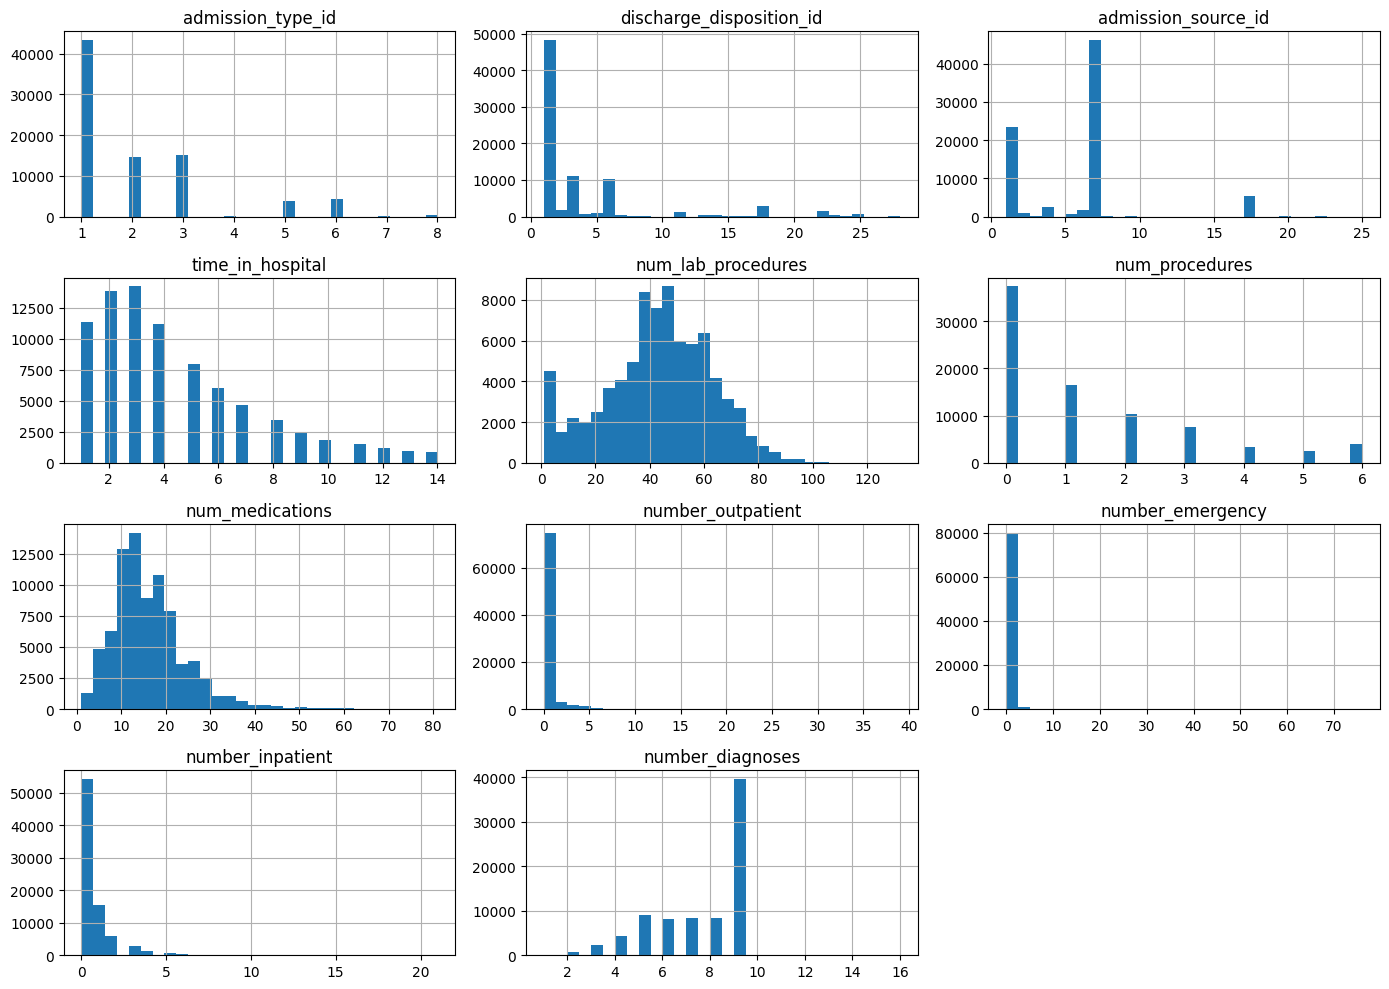

In [20]:
import matplotlib.pyplot as plt

X_train[numeric_features].hist(figsize=(14, 10), bins = 30)
plt.tight_layout()
plt.show()

### Numeric Feature Distribution

Some utilization-related features such as `number_emergency`, `number_outpatient`, and `number_inpatient` are highly right-skewed. This means most patients have low prior visit counts, while a small number of patients have unusually high visit histories.  

This skewness may affect linear models such as Logistic Regression. Therefore, a PowerTransformer / Yeo-Johnson preprocessing variant can be tested for Logistic Regression. Tree-based models such as Random Forest or Gradient Boosting are generally less sensitive to skewed numeric distributions, so they can be trained without this transformation.

In [21]:
from sklearn.preprocessing import PowerTransformer

preprocessor_power = ColumnTransformer(
    transformers = [
        ("num", Pipeline(steps = [
            ("power", PowerTransformer(method="yeo-johnson")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [22]:
log_reg_power_model = Pipeline(
    steps = [
        ("preprocessor", preprocessor_power),
        ("model", LogisticRegression(
            max_iter = 1000,
            class_weight = "balanced",
            random_state = 42
        ))
    ]
)
log_reg_power_model.fit(X_train, y_train)

y_pred = log_reg_power_model.predict(X_test)
y_pred_proba = log_reg_power_model.predict_proba(X_test)[:, 1]

print("Classification Report :")
print(classification_report(y_test, y_pred))

print("ROC-AUC :", roc_auc_score(y_test, y_pred))

print("Confusion Matrix :")
print(confusion_matrix(y_test, y_pred))

Classification Report :
              precision    recall  f1-score   support

           0       0.92      0.63      0.75     18083
           1       0.16      0.57      0.26      2271

    accuracy                           0.63     20354
   macro avg       0.54      0.60      0.50     20354
weighted avg       0.84      0.63      0.70     20354

ROC-AUC : 0.6039140595716318
Confusion Matrix :
[[11450  6633]
 [  966  1305]]


### Logistic Regression with Yeo-Johnson Transformation

The Yeo-Johnson transformation helped the Logistic Regression model identify slightly more positive cases. However, this improvement came with more false positives. Overall, the performance gain was limited.

## Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest does not require scaling, so only categorical encoding is needed.
rf_preprocessor = ColumnTransformer(
    transformers = [
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)
rf_model = Pipeline(
    steps = [
        ("preprocessor", rf_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators = 200,
            max_depth = 12,
            min_samples_leaf = 20,
            class_weight = "balanced",
            random_state = 42,
            n_jobs = -1,
        ))
    ]
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Classification Report :")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC :", roc_auc_score(y_test, y_pred_rf))

print("Confusion Matrix :")
print(confusion_matrix(y_test, y_pred_rf))

Classification Report :
              precision    recall  f1-score   support

           0       0.93      0.62      0.75     18083
           1       0.17      0.60      0.26      2271

    accuracy                           0.62     20354
   macro avg       0.55      0.61      0.50     20354
weighted avg       0.84      0.62      0.69     20354

ROC-AUC : 0.6125054676570507
Confusion Matrix :
[[11275  6808]
 [  905  1366]]


### Random Forest Baseline

Random Forest was tested as a tree-based model because it can capture non-linear relationships and feature interactions better than Logistic Regression.  

Compared with Logistic Regression, Random Forest slightly improved the positive class recall to 0.60 and increased ROC-AUC to 0.613. However, precision remained low at 0.17 and the F1-score stayed at 0.26.  

This suggests that Random Forest captures slightly more readmitted patients, but still produces many false positives.  

## RandomizedSearchCV

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [25]:
rf_search_model = Pipeline(
    steps = [
        ("preprocessor", rf_preprocessor),
        ("model", RandomForestClassifier(
            random_state = 42,
            n_jobs = -1,
            class_weight = "balanced"
        ))
    ]
)

param_distributions = {
    "model__n_estimators": [150, 200, 300],
    "model__max_depth": [8, 12, 16, 20, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [5, 10, 20, 50],
    "model__max_features": ["sqrt", "log2"]
}

rf_random_search = RandomizedSearchCV(
    estimator = rf_search_model,
    param_distributions = param_distributions,
    n_iter = 15,
    scoring = "roc_auc",
    n_jobs = -1,
    cv = 3,
    verbose = 2,
    random_state = 42
)

rf_random_search.fit(X_train, y_train)

print("Best parameters :")
print(rf_random_search.best_params_)

print("Best score :")
print(rf_random_search.best_score_)

print("Best score :")
print(rf_random_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters :
{'model__n_estimators': 200, 'model__min_samples_split': 20, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best score :
0.6565567738310052
Best score :
0.6565567738310052


In [27]:
tuned_rf_model = Pipeline(
    steps = [
        ("preprocessor", rf_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            min_samples_split=20,
            min_samples_leaf=5,
            max_features="sqrt",
            max_depth=None,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

tuned_rf_model.fit(X_train, y_train)

y_pred_tuned_rf = tuned_rf_model.predict(X_test)
y_pred_proba_tuned_rf = tuned_rf_model.predict_proba(X_test)[:, 1]

print("Classification Report :")
print(classification_report(y_test, y_pred_tuned_rf))

print("ROC-AUC :", roc_auc_score(y_test, y_pred_proba_tuned_rf))

print("Confusion Matrix :")
print(confusion_matrix(y_test, y_pred_tuned_rf))

Classification Report :
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     18083
           1       0.20      0.42      0.27      2271

    accuracy                           0.75     20354
   macro avg       0.56      0.61      0.56     20354
weighted avg       0.84      0.75      0.78     20354

ROC-AUC : 0.6729023342704233
Confusion Matrix :
[[14271  3812]
 [ 1313   958]]


In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = [0.20, 0.25, 0.30, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:
  y_pred_threshold = (y_pred_proba_tuned_rf >= threshold).astype(int)

  threshold_results.append({
      "threshold": threshold,
      "accuracy": accuracy_score(y_test, y_pred_threshold),
      "precision_class_1": precision_score(y_test, y_pred_threshold),
      "recall_class_1": recall_score(y_test, y_pred_threshold),
      "f1_class_1": f1_score(y_test, y_pred_threshold)
  })

  threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1
0,0.20,0.111821,0.111603,1.000000,0.200796
1,0.25,0.116046,0.112038,0.999560,0.201491
2,0.30,0.150929,0.115438,0.992074,0.206811
3,0.40,0.419574,0.143146,0.842801,0.244726
4,0.45,0.600423,0.168888,0.658300,0.268812
5,0.50,0.748207,0.200839,0.421841,0.272120


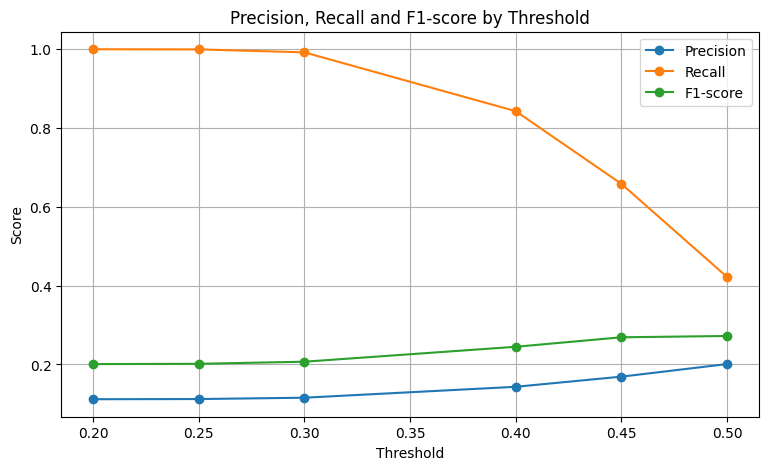

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(threshold_results_df["threshold"], threshold_results_df["precision_class_1"], marker="o", label="Precision")
plt.plot(threshold_results_df["threshold"], threshold_results_df["recall_class_1"], marker="o", label="Recall")
plt.plot(threshold_results_df["threshold"], threshold_results_df["f1_class_1"], marker="o", label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1-score by Threshold")
plt.legend()
plt.grid(True)
plt.show()

### Threshold Tuning Interpretation  ⚗

Lower thresholds classify more patients as high-risk, which increases recall but reduces precision. Higher thresholds reduce false positives but miss more truly readmitted patients.   

In this project, threshold `0.45` provides a more balanced trade-off than the default `0.50`. It keeps recall relatively high while slightly improving precision and F1-score compared with lower thresholds.  

Since the goal is to identify patients at risk of 30-day readmission, the final threshold should be selected based on the desired balance between catching high-risk patients and limiting false alarms.  

## HistGradientBoostingClassifier

In [35]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

hgb_model = Pipeline(
    steps=[
        ("preprocessor", hgb_preprocessor),
        ("model", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=31,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

hgb_model.fit(X_train, y_train)

y_pred_hgb = hgb_model.predict(X_test)
y_pred_proba_hgb = hgb_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_hgb, zero_division=0))

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_hgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_hgb))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.66      0.77     18083
           1       0.18      0.60      0.28      2271

    accuracy                           0.65     20354
   macro avg       0.56      0.63      0.53     20354
weighted avg       0.85      0.65      0.72     20354

ROC-AUC: 0.6827624409028548
Confusion Matrix:
[[11933  6150]
 [  904  1367]]


### HistGradientBoosting Baseline

HistGradientBoosting was tested as another tree-based model that can capture non-linear relationships and feature interactions.  

Compared with the tuned Random Forest model, HistGradientBoosting achieved a higher ROC-AUC score and improved recall for the positive class. Class 1 recall increased to 0.60, meaning the model captured more patients who were actually readmitted within 30 days.  

However, precision remained low at 0.18, which means the model still produces many false positives. Overall, HistGradientBoosting is currently the strongest candidate because it provides the best ROC-AUC and a better recall-oriented trade-off for the readmission risk problem.  

## XGBoost

In [36]:
try:
    from xgboost import XGBClassifier
    print("XGBoost is available.")
except ImportError:
    print("XGBoost is not installed.")

XGBoost is available.


In [39]:
from xgboost import XGBClassifier

# Class imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight

np.float64(7.960158485582214)

In [40]:
xgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

xgb_model = Pipeline(
    steps=[
        ("preprocessor", xgb_preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.65      0.77     18083
           1       0.18      0.61      0.28      2271

    accuracy                           0.65     20354
   macro avg       0.56      0.63      0.52     20354
weighted avg       0.85      0.65      0.71     20354

ROC-AUC: 0.6825600861510137
Confusion Matrix:
[[11836  6247]
 [  884  1387]]


### XGBoost Baseline

XGBoost was tested with `scale_pos_weight` to account for class imbalance. The positive class is much smaller than the negative class, so the imbalance ratio was approximately 7.96.  

The model achieved results very similar to HistGradientBoosting. Class 1 recall reached 0.61, while precision remained at 0.18 and F1-score stayed at 0.28. ROC-AUC was also close to the HistGradientBoosting result.  

Overall, XGBoost slightly improved recall but did not produce a major performance gain over HistGradientBoosting.  

###  Comparision

In [41]:
def evaluate_model(model_name, y_true, y_pred, y_proba):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_Class_1": precision_score(y_true, y_pred, zero_division=0),
        "Recall_Class_1": recall_score(y_true, y_pred, zero_division=0),
        "F1_Class_1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba)
    }

In [44]:
y_pred_power = log_reg_power_model.predict(X_test)
y_pred_proba_power = log_reg_power_model.predict_proba(X_test)[:, 1]

In [45]:
model_results = []

model_results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred,
        y_pred_proba
    )
)

model_results.append(
    evaluate_model(
        "Logistic Regression + Yeo-Johnson",
        y_test,
        y_pred_power,
        y_pred_proba_power
    )
)

model_results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_pred_proba_rf
    )
)

model_results.append(
    evaluate_model(
        "Tuned Random Forest",
        y_test,
        y_pred_tuned_rf,
        y_pred_proba_tuned_rf
    )
)

model_results.append(
    evaluate_model(
        "HistGradientBoosting",
        y_test,
        y_pred_hgb,
        y_pred_proba_hgb
    )
)

model_results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        y_pred_xgb,
        y_pred_proba_xgb
    )
)

model_comparison_df = pd.DataFrame(model_results)

model_comparison_df.sort_values(by="ROC_AUC", ascending=False)

,Model,Accuracy,Precision_Class_1,Recall_Class_1,F1_Class_1,ROC_AUC
4,HistGradientBoosting,0.653434,0.181854,0.601937,0.279322,0.682762
5,XGBoost,0.649651,0.181687,0.610744,0.280061,0.682560
3,Tuned Random Forest,0.748207,0.200839,0.421841,0.272120,0.672902
2,Random Forest,0.621057,0.167115,0.601497,0.261561,0.657231
1,Logistic Regression + Yeo-Johnson,0.626658,0.164399,0.574637,0.255657,0.639903
0,Logistic Regression,0.626658,0.164399,0.574637,0.255657,0.639903


In [46]:
model_comparison_df_sorted = model_comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

model_comparison_df_sorted

,Model,Accuracy,Precision_Class_1,Recall_Class_1,F1_Class_1,ROC_AUC
0,HistGradientBoosting,0.653434,0.181854,0.601937,0.279322,0.682762
1,XGBoost,0.649651,0.181687,0.610744,0.280061,0.682560
2,Tuned Random Forest,0.748207,0.200839,0.421841,0.272120,0.672902
3,Random Forest,0.621057,0.167115,0.601497,0.261561,0.657231
4,Logistic Regression + Yeo-Johnson,0.626658,0.164399,0.574637,0.255657,0.639903
5,Logistic Regression,0.626658,0.164399,0.574637,0.255657,0.639903


HistGradientBoosting and XGBoost produced very similar results. XGBoost achieved slightly higher recall and F1-score for the positive class, while ROC-AUC was almost identical. Therefore, XGBoost was selected as the first model for hyperparameter tuning.

### Hyper-Tuning

In [47]:
xgb_search_model = Pipeline(
    steps=[
        ("preprocessor", xgb_preprocessor),
        ("model", XGBClassifier(
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__gamma": [0, 0.1, 0.3, 0.5]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_search_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(X_train, y_train)

print("Best parameters:")
print(xgb_random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(xgb_random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters:
{'model__subsample': 0.8, 'model__n_estimators': 500, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__gamma': 0.5, 'model__colsample_bytree': 0.7}

Best CV ROC-AUC:
0.6723509716040058


In [48]:
best_xgb_model = xgb_random_search.best_estimator_

y_pred_tuned_xgb = best_xgb_model.predict(X_test)
y_pred_proba_tuned_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_tuned_xgb, zero_division=0))

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_tuned_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned_xgb))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.65      0.77     18083
           1       0.18      0.61      0.28      2271

    accuracy                           0.65     20354
   macro avg       0.56      0.63      0.52     20354
weighted avg       0.85      0.65      0.71     20354

ROC-AUC: 0.6836986055760836
Confusion Matrix:
[[11768  6315]
 [  880  1391]]


### Tuned XGBoost

RandomizedSearchCV was applied to tune the XGBoost model. The tuned model achieved a ROC-AUC score of 0.684 on the test set, which is slightly higher than the baseline XGBoost result.  

The positive class recall remained strong at 0.61, while precision stayed low at 0.18. This means the model can identify a meaningful portion of patients who are readmitted within 30 days, but still produces many false positives.  

Overall, hyperparameter tuning provided only a limited improvement, but Tuned XGBoost is currently one of the strongest model candidates based on ROC-AUC and recall.  

In [49]:
model_results.append(
    evaluate_model(
        "Tuned XGBoost",
        y_test,
        y_pred_tuned_xgb,
        y_pred_proba_tuned_xgb
    )
)

model_comparison_df = pd.DataFrame(model_results)

model_comparison_df_sorted = model_comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

model_comparison_df_sorted

,Model,Accuracy,Precision_Class_1,Recall_Class_1,F1_Class_1,ROC_AUC
0,Tuned XGBoost,0.646507,0.180509,0.612506,0.278841,0.683699
1,HistGradientBoosting,0.653434,0.181854,0.601937,0.279322,0.682762
2,XGBoost,0.649651,0.181687,0.610744,0.280061,0.682560
3,Tuned Random Forest,0.748207,0.200839,0.421841,0.272120,0.672902
4,Random Forest,0.621057,0.167115,0.601497,0.261561,0.657231
5,Logistic Regression + Yeo-Johnson,0.626658,0.164399,0.574637,0.255657,0.639903
6,Logistic Regression,0.626658,0.164399,0.574637,0.255657,0.639903


## Let's try some neural network architecture

In [50]:
import tensorflow as tf
from tensorflow.keras import layers

nn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train_nn = nn_preprocessor.fit_transform(X_train)
X_test_nn = nn_preprocessor.transform(X_test)

X_train_nn.shape, X_test_nn.shape

((81412, 2281), (20354, 2281))

In [51]:
X_train_nn = X_train_nn.toarray()
X_test_nn = X_test_nn.toarray()

In [52]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

class_weights = {
    0: class_weights_array[0],
    1: class_weights_array[1]
}

class_weights

{0: np.float64(0.5628128197328761), 1: np.float64(4.480079242791107)}

In [53]:
tf.random.set_seed(42)

nn_model = tf.keras.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision")
    ]
)

history = nn_model.fit(
    X_train_nn,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=512,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_roc_auc",
            patience=3,
            mode="max",
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.6213 - loss: 0.6699 - precision: 0.1540 - recall: 0.5315 - roc_auc: 0.6186 - val_accuracy: 0.6198 - val_loss: 0.6705 - val_precision: 0.1640 - val_recall: 0.5913 - val_roc_auc: 0.6542
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6219 - loss: 0.6545 - precision: 0.1675 - recall: 0.6004 - roc_auc: 0.6569 - val_accuracy: 0.6073 - val_loss: 0.6543 - val_precision: 0.1598 - val_recall: 0.5957 - val_roc_auc: 0.6538
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6129 - loss: 0.6453 - precision: 0.1702 - recall: 0.6356 - roc_auc: 0.6727 - val_accuracy: 0.6071 - val_loss: 0.6518 - val_precision: 0.1588 - val_recall: 0.5907 - val_roc_auc: 0.6506
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6213 - loss: 0.6348 - precision: 0.1777 - recall: 0.6587 - roc_auc: 0.6898 - val_accuracy: 0.6194 - val_loss: 0.6482 - val_precision: 0.1610 - val_recall: 0.5763 - val_roc_auc: 0.6

In [54]:
y_pred_proba_nn = nn_model.predict(X_test_nn).ravel()
y_pred_nn = (y_pred_proba_nn >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred_nn, zero_division=0))

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_nn))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))

637/637 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.63      0.75     18083
           1       0.17      0.59      0.26      2271

    accuracy                           0.62     20354
   macro avg       0.55      0.61      0.50     20354
weighted avg       0.84      0.62      0.69     20354

ROC-AUC: 0.6576910645864015
Confusion Matrix:
[[11363  6720]
 [  921  1350]]


## Tuned XGBoost + Threshold Decision

In [55]:
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results_xgb = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba_tuned_xgb >= threshold).astype(int)

    threshold_results_xgb.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision_class_1": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall_class_1": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1_class_1": f1_score(y_test, y_pred_threshold, zero_division=0),
        "predicted_positive_count": y_pred_threshold.sum()
    })

threshold_results_xgb_df = pd.DataFrame(threshold_results_xgb)
threshold_results_xgb_df

,threshold,accuracy,precision_class_1,recall_class_1,f1_class_1,predicted_positive_count
0,0.20,0.121647,0.112710,1.000000,0.202587,20149
1,0.25,0.134470,0.113995,0.997798,0.204614,19878
2,0.30,0.179965,0.117588,0.976222,0.209893,18854
3,0.35,0.280191,0.127243,0.930427,0.223870,16606
4,0.40,0.421244,0.143511,0.842801,0.245259,13337
5,0.45,0.536160,0.159673,0.740643,0.262710,10534
6,0.50,0.646507,0.180509,0.612506,0.278841,7706


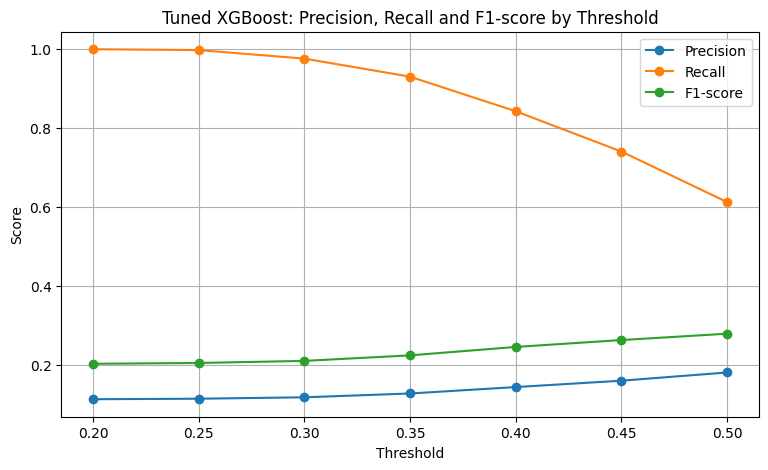

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(threshold_results_xgb_df["threshold"], threshold_results_xgb_df["precision_class_1"], marker="o", label="Precision")
plt.plot(threshold_results_xgb_df["threshold"], threshold_results_xgb_df["recall_class_1"], marker="o", label="Recall")
plt.plot(threshold_results_xgb_df["threshold"], threshold_results_xgb_df["f1_class_1"], marker="o", label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Tuned XGBoost: Precision, Recall and F1-score by Threshold")
plt.legend()
plt.grid(True)
plt.show()

### Threshold Selection

For the tuned XGBoost model, different classification thresholds were tested to evaluate the precision-recall trade-off.  

Lower thresholds such as 0.20–0.30 produce very high recall, but they classify almost all patients as high-risk. This creates too many false positives and may not be practical for a real hospital workflow.  

The default 0.50 threshold gives the highest F1-score, but recall drops to 0.61, meaning more truly readmitted patients are missed.  

A threshold of 0.45 was selected as a balanced option. It keeps recall relatively high at 0.74 while reducing the number of predicted high-risk patients compared with lower thresholds. This is more suitable for a readmission risk screening use case, where missing high-risk patients is more costly than producing some false alarms.  


In [57]:
final_threshold = 0.45

y_pred_final_xgb = (y_pred_proba_tuned_xgb >= final_threshold).astype(int)

print("Final Tuned XGBoost Classification Report:")
print(classification_report(y_test, y_pred_final_xgb, zero_division=0))

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_tuned_xgb))

print("Final Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final_xgb))

Final Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.51      0.66     18083
           1       0.16      0.74      0.26      2271

    accuracy                           0.54     20354
   macro avg       0.55      0.63      0.46     20354
weighted avg       0.85      0.54      0.62     20354

ROC-AUC: 0.6836986055760836
Final Confusion Matrix:
[[9231 8852]
 [ 589 1682]]


## Saving Model

In [65]:
import joblib

final_threshold = 0.45

joblib.dump(best_xgb_model, "/content/drive/MyDrive/BI_Projects/hospital_readmission_prediction/tuned_xgboost_readmission_pipeline.pkl")
joblib.dump(final_threshold, "/content/drive/MyDrive/BI_Projects/hospital_readmission_prediction/final_threshold.pkl")

['/content/drive/MyDrive/BI_Projects/hospital_readmission_prediction/final_threshold.pkl']